In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from PIL import Image
import scipy.optimize as optimize

# Functions

In [2]:
def vertical_profile(x, a, mu, sigma):
    return a * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# Image Analysis

In [3]:
# analysis parameters
shotNum = '11684'
correct_for_saturation = True  # if True, replace saturated values with NaN, fit the signal with gaussian to interpolate

# algo parameters
SAT_LIMIT = 0.80 # anything over 80% saturation is over-saturated

In [4]:
flattened_shotArr_half = None
flattened_shotArr_half_cv = None

try:
    ## LOAD IN RAW IMAGE
    shotImg = Image.open(f'res/test_images/{shotNum}/shot0{shotNum}-1.tif')
    shotArr = np.asarray(shotImg, dtype=float)
    shotImg.close()
    print(f"Processing Shot {shotNum}\nDimensions: {shotArr.shape}")

    image_height, image_width = shotArr.shape

    shotArr_c = np.copy(shotArr)

    # identify oversaturated cells and replace them with NaN
    oversaturated_cells = np.argwhere(shotArr > SAT_LIMIT*255)  # identify oversatured cells
    cols_to_fix = np.unique(oversaturated_cells[:, 1])  # identify which columns need fixing
    print(f"There are {len(oversaturated_cells)} oversaturated cells in the image.")
    print(f"There are {len(cols_to_fix)} columns containing oversaturated cells in the image.")

    # fix the columns (vertically) by imputing gaussian data fit to the unsaturated part
    for c_idx in cols_to_fix:
        corrected_col_idx = []
        corrected_col = []

        for r_idx in range(image_height):
            if shotArr[r_idx, c_idx] <= SAT_LIMIT*255:
                corrected_col_idx.append(r_idx)
                corrected_col.append(shotArr[r_idx, c_idx])
        

        center_guess = np.argmax(shotArr[:, c_idx])

        pguess, _ = optimize.curve_fit(vertical_profile, corrected_col_idx, corrected_col, 
                                    p0=[255, center_guess, 5], 
                                    bounds=([0, 0, 0], [np.inf, image_width, image_width]),
                                    maxfev=100000)

        print(c_idx, pguess)

        x_fine = np.linspace(0, image_height-1, 100)

        # plt.figure(figsize=(6, 4))
        # plt.plot(x_fine, vertical_profile(x_fine, *pguess), color='green')
        # plt.scatter(np.arange(image_height), shotArr[:, c_idx], color='orange')
        # plt.scatter(corrected_col_idx, corrected_col, color='black')

        shotArr_c[:, c_idx] = vertical_profile(np.arange(image_height), *pguess)

    ### Uncorrected (raw) data

    central_columns = np.sort(np.argsort(np.average(shotArr, axis=1))[-2:])  # take two largest average columns as center

    assert central_columns[1] - central_columns[0] == 1, 'Central columns not adjacent!'

    # # show lineouts on processed image

    # plt.imshow(shotArr, cmap='gray')

    # plt.axhline(central_columns[0], color='r', linestyle='-', alpha=0.5)  # s1
    # plt.axhline(central_columns[1], color='r', linestyle='-', alpha=0.5)  # s1

    # plt.axhline(central_columns[0]-1, color='b', linestyle='--', alpha=0.5)  # s2
    # plt.axhline(central_columns[1]+1, color='b', linestyle='--', alpha=0.5)  # s2

    # plt.axhline(central_columns[0]-2, color='r', linestyle='-.', alpha=0.5)  # s3
    # plt.axhline(central_columns[1]+2, color='r', linestyle='-.', alpha=0.5)  # s3

    # plt.axhline(central_columns[0]-3, color='b', linestyle=':', alpha=0.5)  # s4
    # plt.axhline(central_columns[1]+3, color='b', linestyle=':', alpha=0.5)  # s4

    # plt.axhline(central_columns[0]-4, color='r', linestyle=':', alpha=0.5)  # s5
    # plt.axhline(central_columns[1]+4, color='r', linestyle=':', alpha=0.5)  # s5

    shotArr_half = np.array([np.average([shotArr[central_columns[0]-i], shotArr[central_columns[1]+i]], axis=0) for i in range(5)])  # [s1, s2, s3, s4, s5]
    last_row = np.average(shotArr_half[-1].reshape(8, -1), axis=1)  # take the 8-averaged values from the last row
    flattened_shotArr_half = np.concatenate((shotArr_half[:-1].flatten(), last_row)) # this is the 1x200 vector

    row_indices = np.arange(200)
    indexed_data = np.vstack((row_indices, flattened_shotArr_half))

    np.savetxt(f'res/test_images/{shotNum}/{shotNum}_proc_vector.csv', indexed_data.T, delimiter=',', fmt=['%i','%.6f'], header='x_position,signal')
    
    ### Saturation-corrected data

    central_columns = np.sort(np.argsort(np.average(shotArr_c, axis=1))[-2:])  # take two largest average columns as center

    assert central_columns[1] - central_columns[0] == 1, 'Central columns not adjacent!'

    # # show lineouts on processed image

    # plt.imshow(shotArr_c, cmap='gray')

    # plt.axhline(central_columns[0], color='r', linestyle='-', alpha=0.5)  # s1
    # plt.axhline(central_columns[1], color='r', linestyle='-', alpha=0.5)  # s1

    # plt.axhline(central_columns[0]-1, color='b', linestyle='--', alpha=0.5)  # s2
    # plt.axhline(central_columns[1]+1, color='b', linestyle='--', alpha=0.5)  # s2

    # plt.axhline(central_columns[0]-2, color='r', linestyle='-.', alpha=0.5)  # s3
    # plt.axhline(central_columns[1]+2, color='r', linestyle='-.', alpha=0.5)  # s3

    # plt.axhline(central_columns[0]-3, color='b', linestyle=':', alpha=0.5)  # s4
    # plt.axhline(central_columns[1]+3, color='b', linestyle=':', alpha=0.5)  # s4

    # plt.axhline(central_columns[0]-4, color='r', linestyle=':', alpha=0.5)  # s5
    # plt.axhline(central_columns[1]+4, color='r', linestyle=':', alpha=0.5)  # s5

    shotArr_half_c = np.array([np.average([shotArr_c[central_columns[0]-i], shotArr_c[central_columns[1]+i]], axis=0) for i in range(5)])  # [s1, s2, s3, s4, s5]
    last_row_c = np.average(shotArr_half_c[-1].reshape(8, -1), axis=1)  # take the 8-averaged values from the last row
    flattened_shotArr_half_cv = np.concatenate((shotArr_half_c[:-1].flatten(), last_row_c)) # this is the 1x200 vector

    row_indices = np.arange(200)
    indexed_data_c = np.vstack((row_indices, flattened_shotArr_half_cv))

    np.savetxt(f'res/test_images/{shotNum}/{shotNum}_proc_vector_cv.csv', indexed_data_c.T, delimiter=',', fmt=['%i','%.6f'], header='x_position,signal')

    print('(Vertical) Saturation Correction Complete')

except:
    print('48x24 image not found. Unable to generate regular 1x200 vector or vertically saturation-corrected 1x200 vector')

48x24 image not found. Unable to generate regular 1x200 vector or vertically saturation-corrected 1x200 vector


In [5]:
flattened_shotArr_half_ch = None
excel_arr = np.empty(shape=0)
try:
    for i in range(5):
        excel_col = pd.read_excel(f'res/test_images/{shotNum}/s{i+1}final.xlsx',header=None)
        excel_col = excel_col[1].to_numpy()
        excel_arr = np.append(excel_arr, excel_col)

    flattened_shotArr_half_ch = excel_arr
except:
    print('s1final through s5final excel files not found. Unable to compile horizontally saturation-corrected 1x200 vector')

In [6]:
row_indices = np.arange(200)
indexed_data_c = np.vstack((row_indices, flattened_shotArr_half_ch))

np.savetxt(f'res/test_images/{shotNum}/{shotNum}_proc_vector_ch.csv', indexed_data_c.T, delimiter=',', fmt=['%i','%.6f'], header='x_position,signal')


# Plot the saturation corrected data

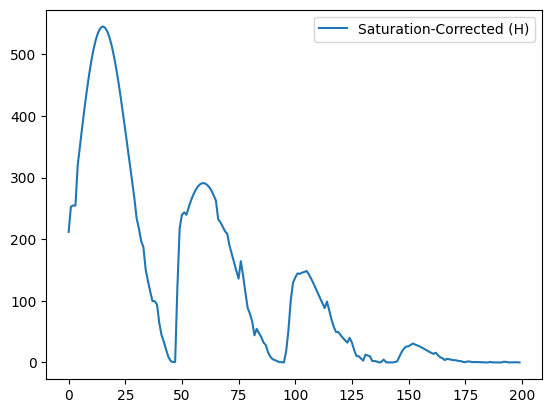

In [7]:
if flattened_shotArr_half is not None:
    plt.plot(flattened_shotArr_half, label='Original')
if flattened_shotArr_half_cv is not None:
    plt.plot(flattened_shotArr_half_cv, label='Saturation-Corrected (V)')
if flattened_shotArr_half_ch is not None:
    plt.plot(flattened_shotArr_half_ch, label='Saturation-Corrected (H)')
plt.legend()
plt.savefig(f'res/test_images/_{shotNum}.png')